# This needs to be your file path!!

In [1]:
import sys, os
import pandas as pd
from pathlib import Path
import re

ELI_lamp_path = "/Users/cmcanespie/Documents/Gemini_cells_2024/Gemini_cells_2024/"

# From here, nothing should change

In [2]:
ROOT_FOLDER = os.path.dirname(ELI_lamp_path) # point this to the folder containing LAMP
print(ROOT_FOLDER)
sys.path.append(ROOT_FOLDER)
from LAMP import Experiment
# ----------------------------------
import matplotlib.pyplot as plt 
import numpy as np
from scipy.signal import savgol_filter

ex = Experiment(ROOT_FOLDER)
ESpec = ex.get_diagnostic('ESpec')

/Users/cmcanespie/Documents/Gemini_cells_2024/Gemini_cells_2024
Initializing LAMP, version 0.2.1
Using DAQ: GeminiMirage
Adding Diagnostic: ESpec [ESpec]


In [3]:
if ex.DAQ.config is None:
    ex.DAQ.config = {}
ex.DAQ.config.setdefault("shotnum_zfill", 0)
print("DAQ config (patched):", ex.DAQ.config)

DAQ config (patched): {'shotnum_zfill': 0}


In [4]:
# /Users/cmcanespie/Documents/Gemini_cells_2024/Mirage/HighEspec/20240306/run05
timeline = {'date': 20240306, 'run': 'run05'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)
shot_dicts

[{'date': 20240306, 'run': 'run05', 'shotnum': 1},
 {'date': 20240306, 'run': 'run05', 'shotnum': 2},
 {'date': 20240306, 'run': 'run05', 'shotnum': 3},
 {'date': 20240306, 'run': 'run05', 'shotnum': 4},
 {'date': 20240306, 'run': 'run05', 'shotnum': 5},
 {'date': 20240306, 'run': 'run05', 'shotnum': 6},
 {'date': 20240306, 'run': 'run05', 'shotnum': 7},
 {'date': 20240306, 'run': 'run05', 'shotnum': 8},
 {'date': 20240306, 'run': 'run05', 'shotnum': 9},
 {'date': 20240306, 'run': 'run05', 'shotnum': 10},
 {'date': 20240306, 'run': 'run05', 'shotnum': 11},
 {'date': 20240306, 'run': 'run05', 'shotnum': 12},
 {'date': 20240306, 'run': 'run05', 'shotnum': 13}]

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'ESpec, Date: 20240306 , Run: run05  '}, ylabel='$E$ [MeV]'>)

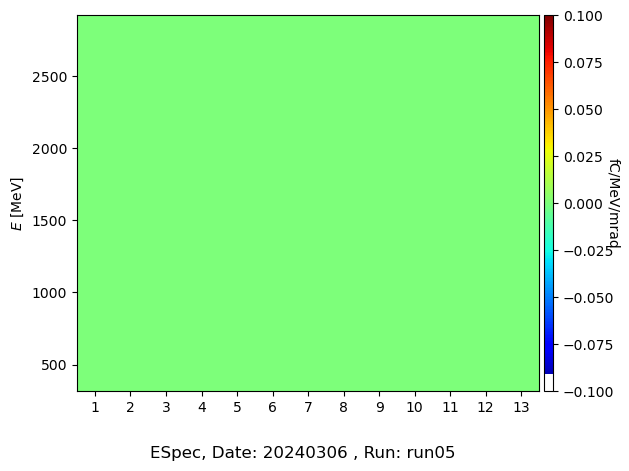

In [6]:
ESpec.montage(timeline)

In [7]:
E_means, E_stds, E_percs, E_charges = ESpec.get_spectra_metrics(timeline, roi_MeV=[500,1600], roi_mrad=None, percentile=90, debug=False)

fig, ax = plt.subplots(1,3,figsize=(12,3))

ax[2].plot(np.arange(len(E_charges))+1, E_charges, '-o')
ax[2].set_xlabel('Shot number')
ax[2].set_ylabel('Background subbed counts [arb.]')

ax[1].plot(np.arange(len(E_means))+1, E_means, '-o')
ax[1].set_xlabel('Shot number')
ax[1].set_ylabel('Mean E [MeV]')

ax[0].plot(np.arange(len(E_percs))+1, E_percs, '-o')
ax[0].set_xlabel('Shot number')
ax[0].set_ylabel('90% Percentile energy [MeV]')

plt.tight_layout()

/opt/anaconda3/lib/python3.13/site-packages/LAMP/diagnostics/ESpec.py:219: RuntimeWarning: invalid value encountered in divide
  spec_dist = np.abs(spec/np.trapz(spec, MeV))


ValueError: array of sample points is empty

# Plot an individual shot

for checking things

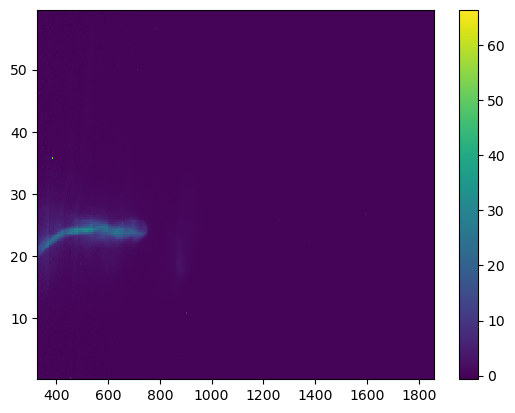

In [6]:
eg_shot = {'date': 20260910, 'run': 'scans/005', 'shotnum': 1}
img, x, y = ESpec.get_proc_shot(eg_shot, debug=False)

plt.pcolormesh(x, y, img)
plt.colorbar()

# Plot overplotted spectra

For when nothing is changed in a run

/var/folders/v8/x5tmn3653v7btc9h58b94mlh0000gn/T/ipykernel_89376/963877323.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  charge.append(abs(np.trapz(spec, x=MeV)))


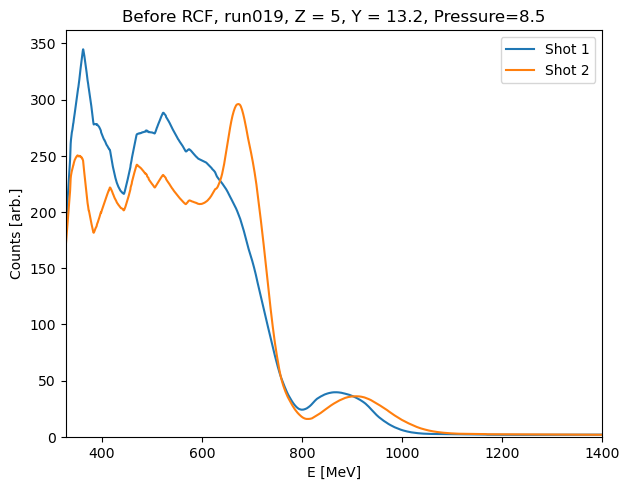

104922.87077344098 3372.8714017940583


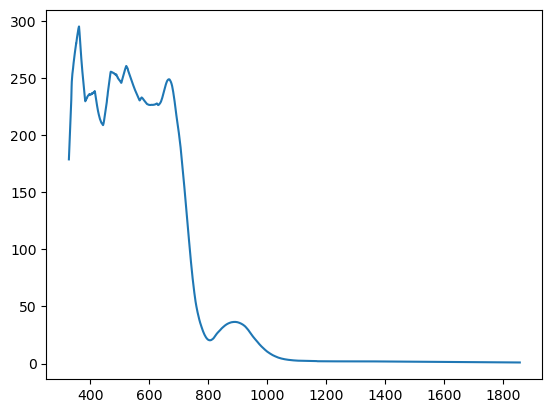

In [7]:
timeline = {'date': 20260910, 'run': 'scans/005'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)

charge = []
ave_spec = []

for n,i in enumerate(shot_dicts):
    img, MeV, y = ESpec.get_proc_shot(i, debug=False)
    img[img<=0] = 0

    spec = abs(np.sum(img, axis=0))
    
    spec = savgol_filter(spec, window_length=61, polyorder=1) # Smooth out the spectra if it has bumps in it
    plt.plot(MeV, spec, label='Shot '+str(n+1))
    charge.append(abs(np.trapz(spec, x=MeV)))
    ave_spec.append(spec)

plt.legend()
plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(np.min(MeV), 1400)
plt.tight_layout()
plt.title('Before RCF, run019, Z = 5, Y = 13.2, Pressure=8.5')
plt.show()

ave_spec_over_run = np.mean(ave_spec, axis=0)

plt.plot(MeV, ave_spec_over_run)

print(np.mean(charge), np.std(charge))